In [1]:
import numpy as np
import matplotlib.pyplot as plt
import inspect
import tqdm as tqdm
import math

In [2]:
def calculate_k_from_l(l):
    keq = l[0]/l[1]
    k = np.array((keq*l[2], keq*l[3], l[4], l[5]))
    return k

## this one (below) seems to work! now waiting for the simulation resutls 

In [3]:
kappa_schloegl = np.array((0.15,0.025,5.75,25.))# calculate_k_from_l(l)

In [4]:
def dx_versus_dt(kappa,a,b,x):
    y = kappa[0]*a*x**2-kappa[1]*x**3-kappa[3]*x+kappa[2]*b
    return y

x_axis = np.linspace(0,50,100000)
y_axis = dx_versus_dt(kappa_schloegl,10,20,x_axis)


In [5]:
a = 10.
b = 20.
vol = 8.
y_axis_abs = abs(y_axis)
idx = np.where(y_axis_abs<0.1)[0]

In [6]:
def get_analytical_dist(p_max, kappa, a, b, vol):
    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol
    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)
    
    # We will compute log(P(n)) to avoid numerical underflow/overflow
    log_p = np.zeros(p_max)
    log_p[0] = 0.0 # Arbitrary unnormalized start
    
    for n in range(1, p_max):
        log_p[n] = log_p[n-1] + np.log(lamb_n(n-1)) - np.log(mu_n(n))
        
    # Subtract max to prevent overflow when doing np.exp()
    log_p -= np.max(log_p)
    
    # Convert back to standard probability and normalize
    p_dist = np.exp(log_p)
    p_dist /= np.sum(p_dist) 
    
    return p_dist

# Now just run it!
p_max = 400
p = np.arange(p_max)
stat_dist = get_analytical_dist(p_max, kappa_schloegl, a, b, vol=8.)

In [7]:
import sys
import os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [8]:
from scripts.analysis.data_loader import load_well_mixed_data
from scripts.analysis.analyze_distributions import hist_np, kde_sk, get_pretty_upper_bound
file_str = "well_mixed_data/" + "schloegl_model_0.15_0.025"
print(f"Loading data from: {file_str}")

# Load data
trajectories, combined_data, metadata = load_well_mixed_data(file_str=file_str)

Loading data from: well_mixed_data/schloegl_model_0.15_0.025
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/well_mixed_data/schloegl_model_0.15_0.025
 Loaded 1 runs. Combined 5000000 points.


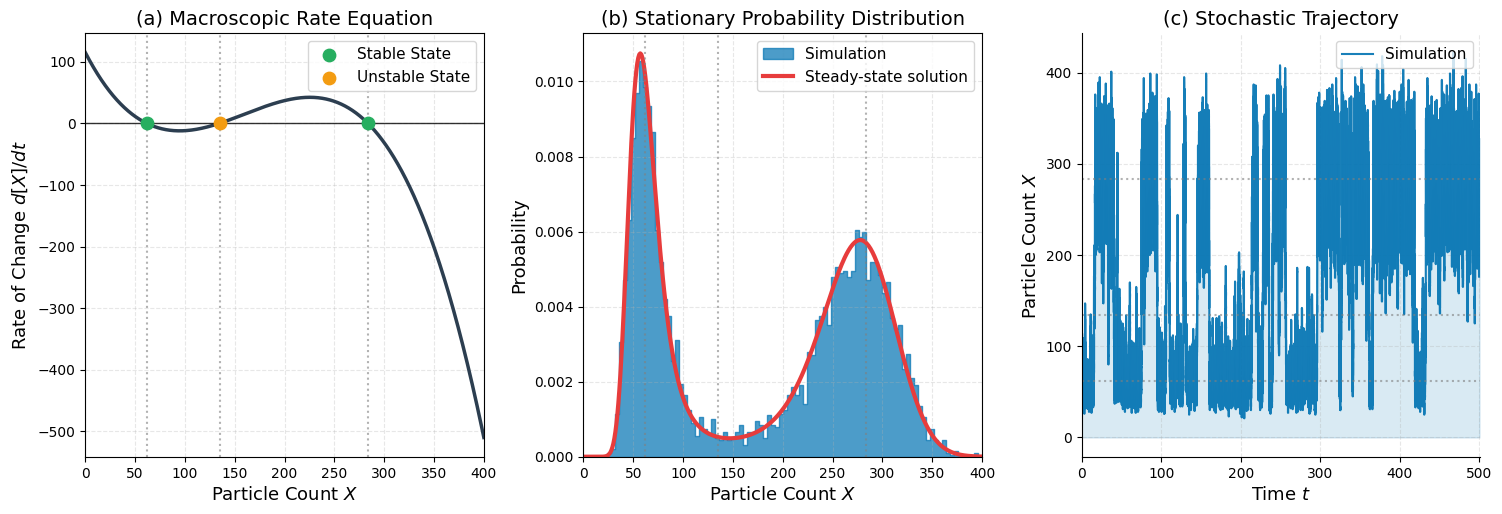

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Automatically find the steady states (where y crosses 0)
roots_x = []
for i in range(len(y_axis)-1):
    if y_axis[i] * y_axis[i+1] < 0:
        x1, x2 = x_axis[i] * vol, x_axis[i+1] * vol
        y1, y2 = y_axis[i], y_axis[i+1]
        root = x1 - y1 * (x2 - x1) / (y2 - y1)
        roots_x.append(root)

# 2. Set up the figure
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))
plt.subplots_adjust(wspace=0.25)

# --- NEW ELEGANT COLOR PALETTE ---
color_ode = '#2C3E50'        # Dark Slate for math/theory
color_analytical = "#E73C3C" # Crimson Red for the analytical target
color_sim = '#0072B2'  #"#3027AE"        # Vibrant Sky Blue for simulation data

# ==========================================
# --- (a) LEFT PLOT: Deterministic ODE ---
# ==========================================
ax[0].plot(x_axis * vol, y_axis, color=color_ode, linewidth=2.5)
ax[0].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.8) 

for i, root in enumerate(roots_x):
    color_dot = '#27AE60' if (i == 0 or i == 2) else '#F39C12' 
    label_text = 'Stable State' if i == 0 else ('Unstable State' if i == 1 else None)
    
    ax[0].axvline(root, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    ax[0].scatter([root], [0], color=color_dot, s=80, zorder=5, label=label_text)

ax[0].set_xlabel('Particle Count $X$', fontsize=13)
ax[0].set_ylabel('Rate of Change $d[X]/dt$', fontsize=13) # $f(X)$
ax[0].set_xlim(0, 400)
ax[0].grid(alpha=0.3, linestyle='--')
ax[0].set_title('(a) Macroscopic Rate Equation', fontsize=14)
ax[0].legend(fontsize=11)


# ==========================================
# --- (b) MIDDLE PLOT: Stochastic Distribution ---
# ==========================================
bin_width = 4.0
combined_data_X = combined_data['X'][::1000]
hist_bin, density_hist = hist_np(combined_data_X, 400, bin_width)

# Plot Simulation as a clean, soft shaded step-line (much nicer than bars!)
# ax[1].plot(hist_bin, density_hist, color=color_sim, drawstyle='steps-mid', alpha=0.9, linewidth=1.5, label='Simulation')
ax[1].fill_between(hist_bin, density_hist, color=color_sim, step='mid', alpha=0.7, label='Simulation')

# Plot Analytical on top as a sharp dashed crimson line
ax[1].plot(p, stat_dist, color=color_analytical, linewidth=3.0, label='Steady-state solution') # linestyle='--'

for root in roots_x:
    ax[1].axvline(root, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)

ax[1].set_xlabel('Particle Count $X$', fontsize=13)
ax[1].set_ylabel('Probability', fontsize=13) # $P(X)
ax[1].set_xlim(0, 400)
ax[1].set_ylim(bottom=0) 
ax[1].grid(alpha=0.3, linestyle='--')
ax[1].set_title('(b) Stationary Probability Distribution', fontsize=14)
ax[1].legend(fontsize=11, loc='upper right')


# ==========================================
# --- (c) RIGHT PLOT: Trajectory ---
# ==========================================
x_time = trajectories[0]['timescale']
y_x = trajectories[0]['species_log']['X']

ax[2].plot(x_time, y_x, color=color_sim, label='Simulation', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
ax[2].fill_between(x_time, y_x, color=color_sim, step='post', alpha=0.15)

for root in roots_x:
    ax[2].axhline(root, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)

ax[2].set_xlabel('Time $t$', fontsize=13)
ax[2].set_ylabel('Particle Count $X$', fontsize=13)
ax[2].set_xlim(left=x_time[0], right=x_time[-1]+1)
ax[2].grid(alpha=0.3, linestyle='--')
ax[2].set_title('(c) Stochastic Trajectory', fontsize=14)
ax[2].legend(fontsize=11, loc='upper right')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

# plt.savefig("schloegl_3panels.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
from scripts.analysis.wd_convergence_analysis import multi_group_wd_comparison

Successfully loaded data for tau=1e-05
Successfully loaded data for tau=5e-07
Successfully loaded data for tau=1e-06
Successfully loaded data for tau=5e-06
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/results/wd_analysis/well_mixed_data


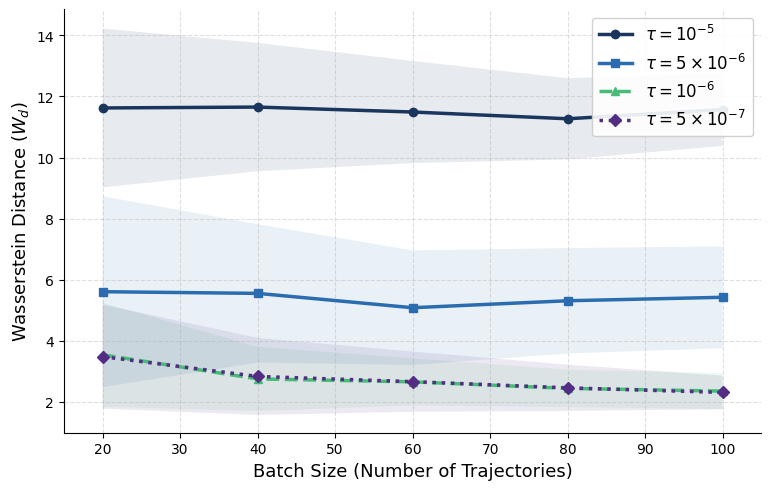

In [11]:
from pathlib import Path
current_dir = Path(os.getcwd()).resolve() # get current working directory
project_root = current_dir.parent

resolution = "well_mixed"
n_iterations = 150
multi_group_wd_comparison(resolution, n_iterations=n_iterations, base_dir=project_root)